In [53]:
%matplotlib inline
import numpy as np
import torch, torch.nn as nn
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


In [ ]:
JOINT_RESULT = 'result_1192k_joint_train_S_rev.pt'
H2O_CSV      = 'hong_1192K_h2o.csv'
OH_CSV       = 'hong_1192K_oh.csv'
YAML_FILE    = 'chem_cti_toy_model_og.yaml'

SIG_LOG     = 0.05
NOISE_FLOOR = 1e-12
LOG_EPS     = 1e-12
INPUT_DIM   = 4
PARAM_NAMES = ['lnA_R22', 'Ea_R22', 'lnA_R26', 'Ea_R26']

SYNTHETIC = False
X_TRUE    = np.array([0.05, 0.0, -0.05, 0.0])  # only used when SYNTHETIC=True

IDX_R22 = 21   # H2O2(+M) <-> OH+OH(+M)  falloff
IDX_R26 = 25   # H2O2+OH  <-> HO2+H2O    Arrhenius

T_INITIAL = 1192
P_INITIAL = 1.95 * ct.one_atm
INITIAL_X = {'H2O2': 2216e-6, 'H2O': 1364e-6, 'O2': 682e-6,
             'AR': 1.0 - (2216 + 1364 + 682) * 1e-6}

DT_SIM  = 1e-6
N_STEPS = 1000
T_SIM   = np.linspace(DT_SIM, DT_SIM * N_STEPS, N_STEPS)  # 1 us ... 1 ms
T_OH    = np.concatenate([
    np.linspace(1e-7, 2e-4, 600),
    np.linspace(2e-4 + 5e-6, 1e-3, 200),
])


In [55]:
class SurrogateNN(nn.Module):
    def __init__(self, hidden, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden), nn.ReLU(), nn.Linear(hidden, n_out))
    def forward(self, x): return self.net(x)


ckpt       = torch.load(JOINT_RESULT, weights_only=False)
N_OH       = int(ckpt["n_oh_targets"])
N_H2O      = int(ckpt["n_h2o_targets"])
N_TOTAL    = N_OH + N_H2O
oh_times   = np.asarray(ckpt["oh_target_times"])
h2o_times  = np.asarray(ckpt["h2o_target_times"])
OH_LABELS  = ckpt.get("oh_labels",  [f"OH_{i}"  for i in range(N_OH)])
H2O_LABELS = ckpt.get("h2o_labels", [f"H2O_{i}" for i in range(N_H2O)])
hidden_dim = int(ckpt["hidden_dim"])
LN_F       = float(ckpt["ln_f"])
SIGMA_E    = float(ckpt["sigma_e"])

model = SurrogateNN(hidden=hidden_dim, n_out=N_TOTAL)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Loaded: {JOINT_RESULT}")
print(f"Architecture : 4 -> {hidden_dim} -> {N_TOTAL}  (OH: {N_OH}, H2O: {N_H2O})")
print(f"LN_F={LN_F}  SIGMA_E={SIGMA_E}")
print(f"OH  target times (ms): {np.round(oh_times*1e3, 4)}")
print(f"H2O target times (ms): {np.round(h2o_times*1e3, 4)}")


Loaded: result_1192k_joint_train.pt
Architecture : 4 -> 16 -> 8  (OH: 5, H2O: 3)
LN_F=3.0  SIGMA_E=5000.0
OH  target times (ms): [0.0029 0.0126 0.0252 0.063  0.5   ]
H2O target times (ms): [0.034 0.121 0.374]


In [56]:
mol_units = ct.UnitSystem({"length":"cm","mass":"g","time":"s","quantity":"mol",
    "pressure":"dyn / cm^2","energy":"erg","temperature":"K","current":"A",
    "activation-energy":"cal / mol"})

_g = ct.Solution(YAML_FILE)
NOM_A_R22  = _g.reaction(IDX_R22).rate.low_rate.pre_exponential_factor
NOM_B_R22  = _g.reaction(IDX_R22).rate.low_rate.temperature_exponent
NOM_EA_R22 = mol_units.convert_activation_energy_to(
    f"{_g.reaction(IDX_R22).rate.low_rate.activation_energy} J/kmol", "cal / mol")
NOM_A_R26  = _g.reaction(IDX_R26).rate.pre_exponential_factor
NOM_B_R26  = _g.reaction(IDX_R26).rate.temperature_exponent
NOM_EA_R26 = mol_units.convert_activation_energy_to(
    f"{_g.reaction(IDX_R26).rate.activation_energy} J/kmol", "cal / mol")
del _g
print(f"R22: A={NOM_A_R22:.3e}  Ea={NOM_EA_R22:.0f} cal/mol")
print(f"R26: A={NOM_A_R26:.3e}  Ea={NOM_EA_R26:.0f} cal/mol")


R22: A=2.490e+21  Ea=48749 cal/mol
R26: A=7.590e+10  Ea=7270 cal/mol


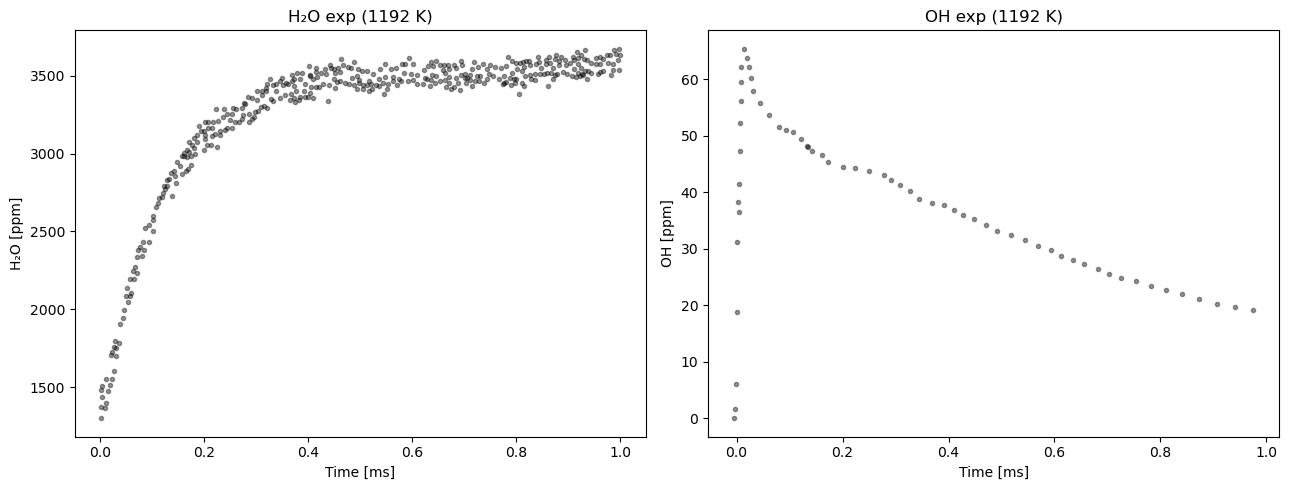

In [57]:
df_h2o = pd.read_csv(H2O_CSV, skipinitialspace=True)
df_oh  = pd.read_csv(OH_CSV,  skipinitialspace=True)

h2o_agg = df_h2o.groupby("Time [ms]")["[H2O] ppm"].mean().reset_index()
t_h2o   = h2o_agg["Time [ms]"].values * 1e-3
y_h2o   = h2o_agg["[H2O] ppm"].values * 1e-6
oh_agg  = df_oh.groupby("Time [ms]")["[OH] ppm"].mean().reset_index()
t_oh    = oh_agg["Time [ms]"].values * 1e-3
y_oh    = oh_agg["[OH] ppm"].values  * 1e-6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "ko", ms=3, alpha=0.4)
ax1.set(xlabel="Time [ms]", ylabel="H₂O [ppm]", title="H₂O exp (1192 K)")
ax2.plot(df_oh["Time [ms]"],  df_oh["[OH] ppm"],  "ko", ms=3, alpha=0.4)
ax2.set(xlabel="Time [ms]", ylabel="OH [ppm]",    title="OH exp (1192 K)")
plt.tight_layout(); plt.show()


In [58]:
if SYNTHETIC:
    rng = np.random.default_rng(0)
    with torch.no_grad():
        _all = model(torch.tensor(X_TRUE, dtype=torch.float32).unsqueeze(0)).numpy().ravel()
    logOH_obs  = _all[:N_OH]  + rng.normal(0, SIG_LOG, N_OH)
    logH2O_obs = _all[N_OH:]  + rng.normal(0, SIG_LOG, N_H2O)
    print(f"[synthetic self-test]  X_TRUE = {X_TRUE}")
else:
    y_oh_at_tgt  = np.interp(oh_times,  t_oh,  y_oh)
    y_h2o_at_tgt = np.interp(h2o_times, t_h2o, y_h2o)
    logOH_obs  = np.log(np.clip(y_oh_at_tgt  + LOG_EPS, NOISE_FLOOR, None))
    logH2O_obs = np.log(np.clip(y_h2o_at_tgt + LOG_EPS, NOISE_FLOOR, None))
    print("OH  exp at surrogate target times:")
    for lbl, t, v in zip(OH_LABELS,  oh_times,  y_oh_at_tgt):
        print(f"  {lbl:<24}  t={t*1e3:.4f} ms   {v*1e6:.2f} ppm")
    print("H2O exp at surrogate target times:")
    for lbl, t, v in zip(H2O_LABELS, h2o_times, y_h2o_at_tgt):
        print(f"  {lbl:<24}  t={t*1e3:.4f} ms   {v*1e6:.2f} ppm")


OH  exp at surrogate target times:
  rise (50% up)             t=0.0029 ms   37.33 ppm
  [OH]_peak                 t=0.0126 ms   64.61 ppm
  OH @ 2*t_peak             t=0.0252 ms   61.13 ppm
  OH @ 5*t_peak             t=0.0630 ms   53.42 ppm
  OH @ 0.5ms                t=0.5000 ms   32.99 ppm
H2O exp at surrogate target times:
  H2O 20% rise              t=0.0340 ms   1762.28 ppm
  H2O 60% rise              t=0.1210 ms   2758.83 ppm
  H2O 95% rise              t=0.3740 ms   3342.19 ppm


In [59]:
def nn_log_all(x_vec):
    """Joint NN forward pass -> log-space predictions, shape (N_TOTAL,)."""
    with torch.no_grad():
        x_t = torch.tensor(x_vec, dtype=torch.float32).unsqueeze(0)
        return model(x_t).squeeze(0).numpy()


def nn_jacobian(x_vec):
    """Analytic Jacobian of the joint NN: shape (N_TOTAL, INPUT_DIM)."""
    x_t = torch.tensor(x_vec, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    J = torch.autograd.functional.jacobian(lambda xx: model(xx).squeeze(0), x_t)
    return J.detach().numpy().reshape(N_TOTAL, INPUT_DIM)


def residual(x_vec, use_oh=True, use_h2o=True):
    log_pred = nn_log_all(x_vec)
    parts = []
    if use_oh:  parts.append((log_pred[:N_OH] - logOH_obs)  / SIG_LOG)
    if use_h2o: parts.append((log_pred[N_OH:] - logH2O_obs) / SIG_LOG)
    return np.concatenate(parts)


def residual_jac(x_vec, use_oh=True, use_h2o=True):
    J = nn_jacobian(x_vec) / SIG_LOG
    parts = []
    if use_oh:  parts.append(J[:N_OH])
    if use_h2o: parts.append(J[N_OH:])
    return np.vstack(parts)


def solve(use_oh, use_h2o, label):
    sol = least_squares(
        lambda x: residual(x, use_oh, use_h2o),
        x0=np.zeros(INPUT_DIM),
        jac=lambda x: residual_jac(x, use_oh, use_h2o),
        bounds=([-1.0]*INPUT_DIM, [1.0]*INPUT_DIM),
        method="trf", verbose=0)
    cov = np.linalg.inv(sol.jac.T @ sol.jac + np.eye(INPUT_DIM))
    sig = np.sqrt(np.diag(cov))
    n_d = (N_OH if use_oh else 0) + (N_H2O if use_h2o else 0)
    print(f'\n{"="*66}\n  {label}\n{"="*66}')
    print(f"  cost={0.5*np.sum(sol.fun**2):.4g}  ({n_d} obs pts)")
    print(f"  {'param':<18}{'x*':>9}{'post_sig_x':>12}{'post_lnf':>11}")
    for n, xv, sv in zip(PARAM_NAMES, sol.x, sig):
        print(f"  {n:<18}{xv:>9.4f}{sv:>12.4f}{sv*LN_F:>11.4f}")
    return sol.x, cov


solve(False, True,  "H2O ONLY   (k2 ridge -- flat posterior)")
solve(True,  False, "OH ONLY    (constrains k1/k2 ratio)")
x_opt, Sigma_star = solve(True, True, "JOINT OH+H2O  <-- full constraint")
sig_opt = np.sqrt(np.diag(Sigma_star))



  H2O ONLY   (k2 ridge -- flat posterior)
  cost=0.143  (3 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R22             -0.5966      0.5774     1.7321
  Ea_R22              -0.9995      0.8195     2.4585
  lnA_R26              0.0497      0.6470     1.9409
  Ea_R26               1.0000      0.8455     2.5364

  OH ONLY    (constrains k1/k2 ratio)
  cost=2.214  (5 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R22             -0.6782      0.5752     1.7255
  Ea_R22              -1.0000      0.8158     2.4473
  lnA_R26              0.8030      0.5712     1.7137
  Ea_R26               1.0000      0.8156     2.4467

  JOINT OH+H2O  <-- full constraint
  cost=3.083  (8 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R22             -0.6832      0.5744     1.7232
  Ea_R22              -1.0000      0.8152     2.4455
  lnA_R26              0.7986      0.5710     1.7130
  Ea_R26               1.0000      0.8149     2.4448


In [60]:
A22_opt  = NOM_A_R22 * np.exp(x_opt[0] * LN_F)
Ea22_opt = NOM_EA_R22 + x_opt[1] * SIGMA_E
A26_opt  = NOM_A_R26 * np.exp(x_opt[2] * LN_F)
Ea26_opt = NOM_EA_R26 + x_opt[3] * SIGMA_E
phys_sc   = np.array([LN_F, SIGMA_E, LN_F, SIGMA_E])
post_phys = sig_opt * phys_sc

print("=" * 70)
print("  Optimized rate parameters at joint MAP estimate")
print("=" * 70)
print(f"  R22 (k1)  A : {NOM_A_R22:.3e} -> {A22_opt:.3e}  "
      f"(x{np.exp(x_opt[0]*LN_F):.3f})  2σ: x{np.exp(2*post_phys[0]):.2f}")
print(f"  R22 (k1) Ea : {NOM_EA_R22:.0f} -> {Ea22_opt:.0f} cal/mol  "
      f"(shift {x_opt[1]*SIGMA_E:+.0f})  2σ: ±{2*post_phys[1]:.0f} cal/mol")
print(f"  R26 (k2)  A : {NOM_A_R26:.3e} -> {A26_opt:.3e}  "
      f"(x{np.exp(x_opt[2]*LN_F):.3f})  2σ: x{np.exp(2*post_phys[2]):.2f}")
print(f"  R26 (k2) Ea : {NOM_EA_R26:.0f} -> {Ea26_opt:.0f} cal/mol  "
      f"(shift {x_opt[3]*SIGMA_E:+.0f})  2σ: ±{2*post_phys[3]:.0f} cal/mol")

if SYNTHETIC:
    print(f"\n  Recovery error |x* - X_TRUE| = {np.abs(x_opt - X_TRUE)}")


  Optimized rate parameters at joint MAP estimate
  R22 (k1)  A : 2.490e+21 -> 3.207e+20  (x0.129)  2σ: x31.39
  R22 (k1) Ea : 48749 -> 43749 cal/mol  (shift -5000)  2σ: ±8152 cal/mol
  R26 (k2)  A : 7.590e+10 -> 8.333e+11  (x10.978)  2σ: x30.75
  R26 (k2) Ea : 7270 -> 12270 cal/mol  (shift +5000)  2σ: ±8149 cal/mol


In [61]:
def _perturb_gas(x_vec):
    gas = ct.Solution(YAML_FILE)
    A22  = NOM_A_R22 * np.exp(x_vec[0] * LN_F)
    Ea22 = (NOM_EA_R22 + x_vec[1] * SIGMA_E) * 4184.0  # cal/mol -> J/kmol
    rxn22 = gas.reaction(IDX_R22)
    rxn22.rate.low_rate = ct.Arrhenius(A22, NOM_B_R22, Ea22)
    gas.modify_reaction(IDX_R22, rxn22)
    A26  = NOM_A_R26 * np.exp(x_vec[2] * LN_F)
    Ea26 = (NOM_EA_R26 + x_vec[3] * SIGMA_E) * 4184.0
    rxn26 = gas.reaction(IDX_R26)
    rxn26.rate = ct.Arrhenius(A26, NOM_B_R26, Ea26)
    gas.modify_reaction(IDX_R26, rxn26)
    return gas


def _run_profiles(x_vec):
    """Single Cantera run -> H2O on T_SIM grid and OH on T_OH grid."""
    gas = _perturb_gas(x_vec)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
    net     = ct.ReactorNet([reactor])
    h2o_idx = gas.species_index("H2O")
    oh_idx  = gas.species_index("OH")
    # Merge grids; all_t[:N_STEPS]=T_SIM, all_t[N_STEPS:]=T_OH.
    # After sorting and advancing, output[i] = value at time all_t[i].
    all_t    = np.concatenate([T_SIM, T_OH])
    order    = np.argsort(all_t, kind="stable")
    h2o_vals = np.empty(len(all_t))
    oh_vals  = np.empty(len(all_t))
    for k, t in enumerate(all_t[order]):
        net.advance(t)
        h2o_vals[order[k]] = reactor.thermo.X[h2o_idx]
        oh_vals[order[k]]  = reactor.thermo.X[oh_idx]
    return h2o_vals[:N_STEPS], oh_vals[N_STEPS:]


print("Cantera at x=0 (nominal) ...")
h2o_nom, oh_nom = _run_profiles(np.zeros(INPUT_DIM))
print("Cantera at x* (MAP estimate) ...")
h2o_opt, oh_opt = _run_profiles(x_opt)
print("Done.")


Cantera at x=0 (nominal) ...
Cantera at x* (MAP estimate) ...
Done.


/tmp/ipykernel_2337502/263577736.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(A22, NOM_B_R22, Ea22)
/tmp/ipykernel_2337502/263577736.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(A26, NOM_B_R26, Ea26)
/tmp/ipykernel_2337502/263577736.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_2337502/263577736.py:32: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  h2o_vals[order[k]] = reactor.thermo.X[h2o_idx]
/tmp/ipykernel_2337502/263577736.py

In [62]:
EPS_FD = 1e-3
print(f"Computing FD Cantera Jacobian at x* ({INPUT_DIM} runs) ...")

log_h2o_base = np.log(np.clip(h2o_opt, 1e-30, None))
log_oh_base  = np.log(np.clip(oh_opt,  1e-30, None))
J_h2o = np.zeros((N_STEPS,   INPUT_DIM))
J_oh  = np.zeros((len(T_OH), INPUT_DIM))

for k in range(INPUT_DIM):
    dx = np.zeros(INPUT_DIM); dx[k] = EPS_FD
    h2o_p, oh_p = _run_profiles(x_opt + dx)
    J_h2o[:, k] = (np.log(np.clip(h2o_p, 1e-30, None)) - log_h2o_base) / EPS_FD
    J_oh[:, k]  = (np.log(np.clip(oh_p,  1e-30, None)) - log_oh_base)  / EPS_FD
    print(f"  {PARAM_NAMES[k]} done")

from scipy.ndimage import uniform_filter1d
J_oh  = uniform_filter1d(J_oh,  size=20, axis=0)  # smooth time-shift artifact
J_h2o = uniform_filter1d(J_h2o, size=20, axis=0)
h2o_logvar = np.einsum("ti,ij,tj->t", J_h2o, Sigma_star, J_h2o)
oh_logvar  = np.einsum("ti,ij,tj->t", J_oh,  Sigma_star, J_oh)
h2o_upper  = h2o_opt * np.exp(+2 * np.sqrt(h2o_logvar))
h2o_lower  = h2o_opt * np.exp(-2 * np.sqrt(h2o_logvar))
oh_upper   = oh_opt  * np.exp(+2 * np.sqrt(oh_logvar))
oh_lower   = oh_opt  * np.exp(-2 * np.sqrt(oh_logvar))
print("Posterior bands done.")


Computing FD Cantera Jacobian at x* (4 runs) ...
  lnA_R22 done
  Ea_R22 done
  lnA_R26 done
  Ea_R26 done


Posterior bands done.


/tmp/ipykernel_2337502/263577736.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(A22, NOM_B_R22, Ea22)
/tmp/ipykernel_2337502/263577736.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(A26, NOM_B_R26, Ea26)
/tmp/ipykernel_2337502/263577736.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_2337502/263577736.py:32: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  h2o_vals[order[k]] = reactor.thermo.X[h2o_idx]
/tmp/ipykernel_2337502/263577736.py

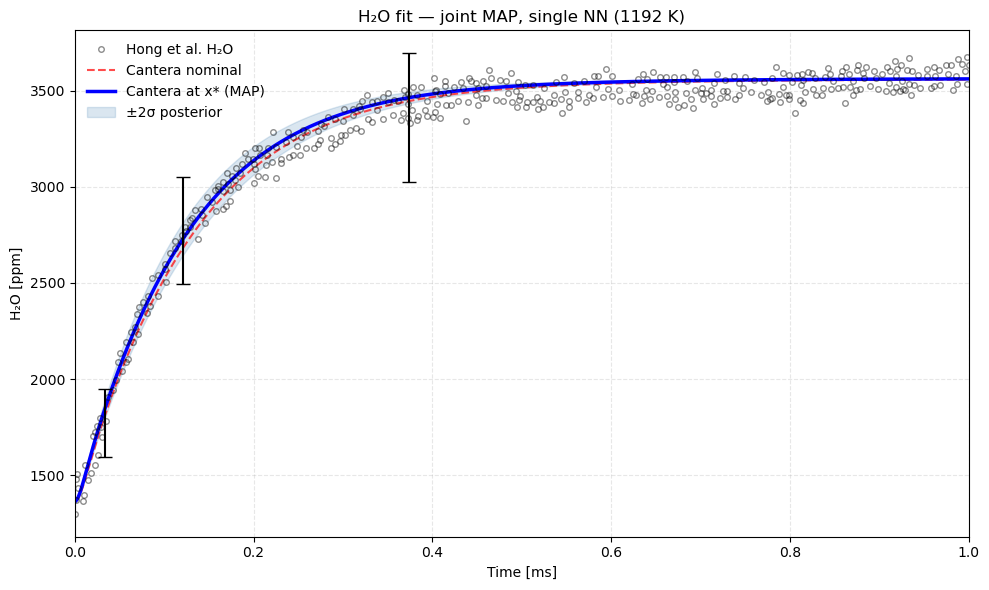

In [63]:
if not SYNTHETIC:
    y_exp_h2o_ppm = y_h2o_at_tgt * 1e6
    yerr_up = y_exp_h2o_ppm * (np.exp(+2*SIG_LOG) - 1)
    yerr_dn = y_exp_h2o_ppm * (1 - np.exp(-2*SIG_LOG))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "o",
        mfc="none", mec="k", ms=4, alpha=0.45, zorder=3, label="Hong et al. H₂O")
if not SYNTHETIC:
    ax.errorbar(h2o_times*1e3, y_exp_h2o_ppm,
                yerr=[yerr_dn, yerr_up],
                fmt="none", ecolor="k", elinewidth=1.5, capsize=5, zorder=4)
ax.plot(T_SIM*1e3, h2o_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Cantera nominal")
ax.plot(T_SIM*1e3, h2o_opt*1e6, "b-",  lw=2.5, label="Cantera at x* (MAP)")
ax.fill_between(T_SIM*1e3, h2o_lower*1e6, h2o_upper*1e6,
                color="steelblue", alpha=0.20, label="±2σ posterior")
ax.set(xlabel="Time [ms]", ylabel="H₂O [ppm]",
       xlim=[0, 1.0], title="H₂O fit — joint MAP, single NN (1192 K)")
ax.legend(frameon=False); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout(); plt.show()


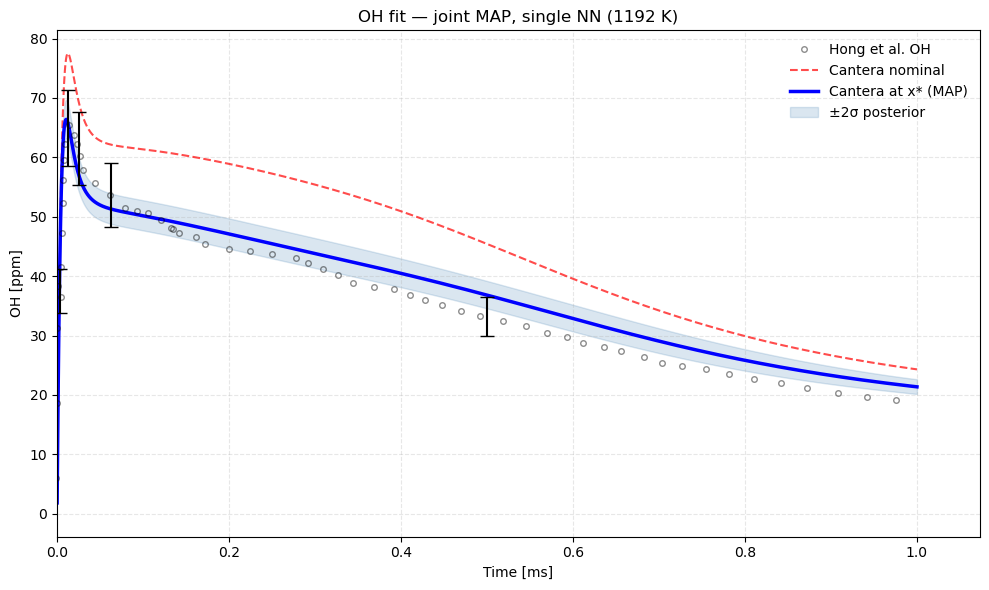

In [64]:
if not SYNTHETIC:
    y_exp_oh_ppm = y_oh_at_tgt * 1e6
    yerr_oh_up = y_exp_oh_ppm * (np.exp(+2*SIG_LOG) - 1)
    yerr_oh_dn = y_exp_oh_ppm * (1 - np.exp(-2*SIG_LOG))
oh_xlim = max(t_oh.max()*1e3 * 1.1, 0.06)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_oh["Time [ms]"], df_oh["[OH] ppm"], "o",
        mfc="none", mec="k", ms=4, alpha=0.45, zorder=3, label="Hong et al. OH")
if not SYNTHETIC:
    ax.errorbar(oh_times*1e3, y_exp_oh_ppm,
                yerr=[yerr_oh_dn, yerr_oh_up],
                fmt="none", ecolor="k", elinewidth=1.5, capsize=5, zorder=4)
ax.plot(T_OH*1e3, oh_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Cantera nominal")
ax.plot(T_OH*1e3, oh_opt*1e6, "b-",  lw=2.5, label="Cantera at x* (MAP)")
ax.fill_between(T_OH*1e3, oh_lower*1e6, oh_upper*1e6,
                color="steelblue", alpha=0.20, label="±2σ posterior")
ax.set(xlabel="Time [ms]", ylabel="OH [ppm]",
       xlim=[0, oh_xlim], title="OH fit — joint MAP, single NN (1192 K)")
ax.legend(frameon=False); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout(); plt.show()


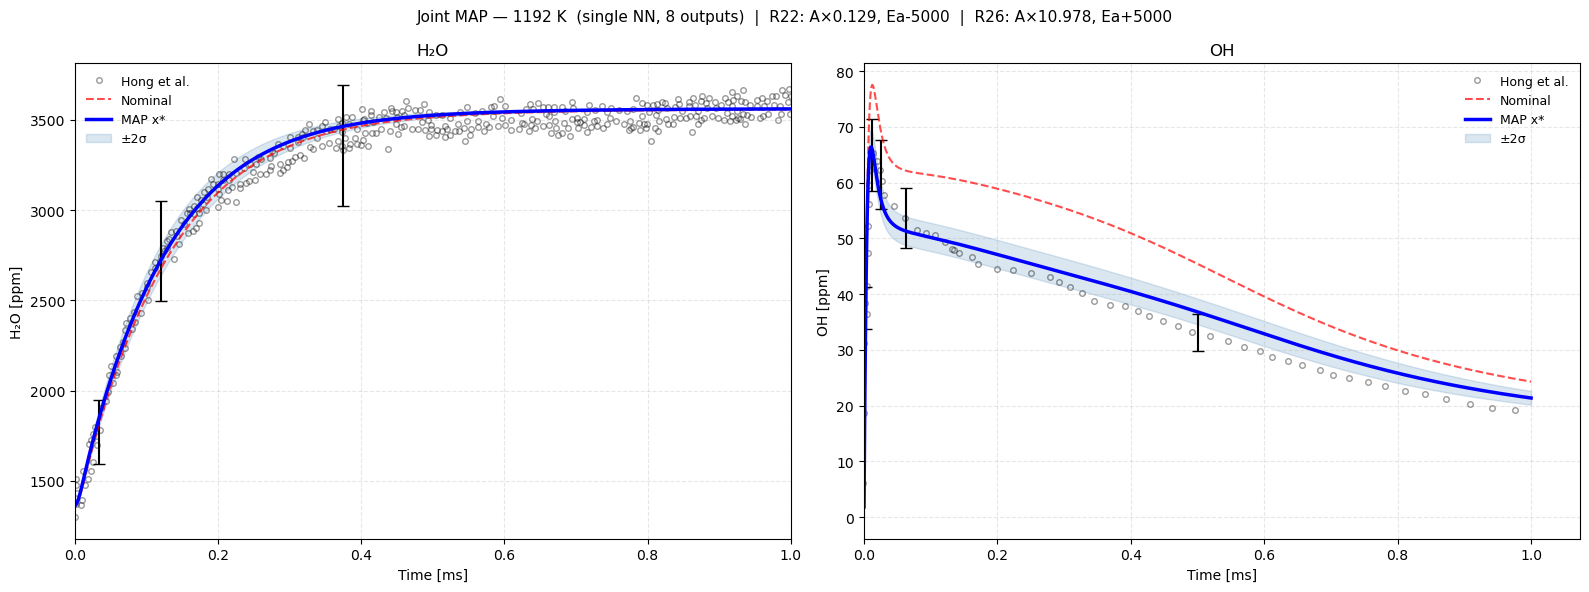

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "o",
         mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
if not SYNTHETIC:
    ax1.errorbar(h2o_times*1e3, y_exp_h2o_ppm,
                 yerr=[yerr_dn, yerr_up], fmt="none",
                 ecolor="k", elinewidth=1.5, capsize=4)
ax1.plot(T_SIM*1e3, h2o_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Nominal")
ax1.plot(T_SIM*1e3, h2o_opt*1e6, "b-",  lw=2.5, label="MAP x*")
ax1.fill_between(T_SIM*1e3, h2o_lower*1e6, h2o_upper*1e6,
                 color="steelblue", alpha=0.20, label="±2σ")
ax1.set(xlabel="Time [ms]", ylabel="H₂O [ppm]", xlim=[0, 1.0], title="H₂O")
ax1.legend(frameon=False, fontsize=9); ax1.grid(True, ls="--", alpha=0.3)

ax2.plot(df_oh["Time [ms]"], df_oh["[OH] ppm"], "o",
         mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
if not SYNTHETIC:
    ax2.errorbar(oh_times*1e3, y_exp_oh_ppm,
                 yerr=[yerr_oh_dn, yerr_oh_up], fmt="none",
                 ecolor="k", elinewidth=1.5, capsize=4)
ax2.plot(T_OH*1e3, oh_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Nominal")
ax2.plot(T_OH*1e3, oh_opt*1e6, "b-",  lw=2.5, label="MAP x*")
ax2.fill_between(T_OH*1e3, oh_lower*1e6, oh_upper*1e6,
                 color="steelblue", alpha=0.20, label="±2σ")
ax2.set(xlabel="Time [ms]", ylabel="OH [ppm]", xlim=[0, oh_xlim], title="OH")
ax2.legend(frameon=False, fontsize=9); ax2.grid(True, ls="--", alpha=0.3)

fig.suptitle(
    f"Joint MAP — 1192 K  (single NN, {N_TOTAL} outputs)  |  "
    f"R22: A×{np.exp(x_opt[0]*LN_F):.3f}, Ea{x_opt[1]*SIGMA_E:+.0f}  |  "
    f"R26: A×{np.exp(x_opt[2]*LN_F):.3f}, Ea{x_opt[3]*SIGMA_E:+.0f}",
    fontsize=11)
plt.tight_layout(); plt.show()
